In [1]:
import pandas as pd
df=pd.read_csv("datos_frontur_0725.txt",sep=";")
df.head()

,A0,A0_1,A0_7,A1,Residencia,CCAA,A14,A15,A16,A13_1,Factor
0,1,20250703036247,2,2,13,4,1,1,6,6,279.706133
1,1,20250700036247,2,2,13,4,1,1,6,6,279.706133
2,1,20250701036247,2,2,13,4,1,1,6,6,279.706133
3,1,20250702036247,2,2,13,4,1,1,6,6,279.706133
4,1,20250704036247,2,2,13,4,1,1,6,6,279.706133


In [2]:
df.shape

(85574, 11)

In [3]:
import glob

archivos = glob.glob("datos_frontur_*.txt")
print(archivos)  # comprobar que coge los 12

['datos_frontur_0126.txt', 'datos_frontur_0226.txt', 'datos_frontur_0326.txt', 'datos_frontur_0426.txt', 'datos_frontur_0526.txt', 'datos_frontur_0626.txt', 'datos_frontur_0725.txt', 'datos_frontur_0825.txt', 'datos_frontur_0925.txt', 'datos_frontur_1025.txt', 'datos_frontur_1125.txt', 'datos_frontur_1225.txt']


In [4]:
lista_df = []

for archivo in archivos:
    temp = pd.read_csv(archivo, sep=";")
    lista_df.append(temp)

df = pd.concat(lista_df, ignore_index=True)
df.shape

(790548, 11)

In [5]:
df['A0_1'].astype(str).head(10)

0    20250100014376
1    20260100022905
2    20260100029165
3    20251200023713
4    20260100026696
5    20260100014614
6    20260100005682
7    20260101019458
8    20260100013045
9    20260100031646
Name: A0_1, dtype: str

In [6]:
df['A0_1'] = df['A0_1'].astype(str)

df['anio'] = df['A0_1'].str[:4]
df['mes'] = df['A0_1'].str[4:6]

df[['A0_1', 'anio', 'mes']].head(10)

,A0_1,anio,mes
0,20250100014376,2025,01
1,20260100022905,2026,01
2,20260100029165,2026,01
3,20251200023713,2025,12
4,20260100026696,2026,01
5,20260100014614,2026,01
6,20260100005682,2026,01
7,20260101019458,2026,01
8,20260100013045,2026,01
9,20260100031646,2026,01


In [7]:
df.groupby(['anio', 'mes']).size()

anio  mes
2016  01        16
      06        12
      07        20
      08        29
      09         8
             ...  
2026  02     49328
      03     52583
      04     70475
      05     57358
      06     47434
Length: 78, dtype: int64

In [8]:
df.groupby(['anio', 'mes']).size().to_string()

'anio  mes\n2016  01        16\n      06        12\n      07        20\n      08        29\n      09         8\n      10         7\n      12         3\n2020  01        36\n      02        24\n      07        20\n      08        30\n      09        11\n      10         6\n      11         5\n      12         6\n2021  01        12\n      05         9\n      06        24\n      07        57\n      08        81\n      09        44\n      10        29\n      11         8\n      12        45\n2022  01        38\n      02        91\n      03        65\n      04       106\n      05        40\n      06        85\n      07       152\n      08       131\n      09       172\n      10       119\n      11        95\n      12       252\n2023  01        92\n      02        76\n      03        92\n      04       259\n      05       153\n      06       197\n      07       781\n      08       944\n      09       854\n      10       798\n      11       431\n      12       409\n2024  01       388\n      02

In [9]:
meses_validos = [
    ('2025','07'), ('2025','08'), ('2025','09'), ('2025','10'), ('2025','11'), ('2025','12'),
    ('2026','01'), ('2026','02'), ('2026','03'), ('2026','04'), ('2026','05'), ('2026','06')
]

df['anio_mes'] = list(zip(df['anio'], df['mes']))
df_limpio = df[df['anio_mes'].isin(meses_validos)]

df_limpio.shape

(755523, 14)

In [10]:
df_limpio = df_limpio.rename(columns={
    'A0': 'encuesta',
    'A0_1': 'id',
    'A0_7': 'tipo_viajero',
    'A1': 'via_entrada',
    'Residencia': 'pais_origen',
    'CCAA': 'comunidad_autonoma',
    'A14': 'alojamiento',
    'A15': 'motivo',
    'A16': 'paquete',
    'A13_1': 'duracion',
    'Factor': 'factor'
})

df_limpio.head()

,encuesta,id,tipo_viajero,via_entrada,pais_origen,comunidad_autonoma,alojamiento,motivo,paquete,duracion,factor,anio,mes,anio_mes
1,1,20260100022905,2,2,13.0,9,1,1,6,3,69.613788,2026,01,"(2026, 01)"
2,1,20260100029165,2,2,13.0,9,2,1,6,3,205.920106,2026,01,"(2026, 01)"
3,1,20251200023713,2,4,13.0,10,7,1,6,5,19.949851,2025,12,"(2025, 12)"
4,1,20260100026696,3,2,13.0,98,0,2,6,1,55.130582,2026,01,"(2026, 01)"
5,1,20260100014614,2,2,13.0,13,1,5,6,2,268.610579,2026,01,"(2026, 01)"


In [11]:
paises = {
    1: 'Alemania', 2: 'Bélgica', 3: 'España', 4: 'Francia', 5: 'Irlanda',
    6: 'Italia', 7: 'Países Bajos', 8: 'Portugal', 9: 'Reino Unido',
    10: 'Países Nórdicos', 11: 'Rusia', 12: 'Suiza', 13: 'Resto de Europa',
    14: 'Estados Unidos', 15: 'América (sin EEUU)', 16: 'Resto del mundo'
}

ccaa = {
    1: 'Andalucía', 2: 'Aragón', 3: 'Asturias', 4: 'Baleares', 5: 'Canarias',
    6: 'Cantabria', 7: 'Castilla y León', 8: 'Castilla La Mancha', 9: 'Cataluña',
    10: 'Com. Valenciana', 11: 'Extremadura', 12: 'Galicia', 13: 'Com. Madrid',
    14: 'Región de Murcia', 15: 'C.F. Navarra', 16: 'País Vasco', 17: 'La Rioja',
    18: 'Ceuta', 19: 'Melilla', 98: 'Tránsito'
}

alojamiento = {
    1: 'Hoteles y similares', 2: 'Alojamiento alquiler', 3: 'Camping',
    4: 'Casa rural', 5: 'Crucero', 6: 'Otro alojamiento mercado',
    7: 'Vivienda en propiedad', 8: 'Vivienda familiares/amigos',
    9: 'Otro alojamiento no mercado', 0: 'No procede'
}

motivo = {
    0: 'No procede', 1: 'Ocio/vacaciones', 2: 'Negocios',
    3: 'Estudios', 4: 'Personal (salud, familia)', 5: 'Otros motivos'
}

df_limpio['pais_origen'] = df_limpio['pais_origen'].map(paises)
df_limpio['comunidad_autonoma'] = df_limpio['comunidad_autonoma'].map(ccaa)
df_limpio['alojamiento'] = df_limpio['alojamiento'].map(alojamiento)
df_limpio['motivo'] = df_limpio['motivo'].map(motivo)

df_limpio.head()

,encuesta,id,tipo_viajero,via_entrada,pais_origen,comunidad_autonoma,alojamiento,motivo,paquete,duracion,factor,anio,mes,anio_mes
1,1,20260100022905,2,2,Resto de Europa,Cataluña,Hoteles y similares,Ocio/vacaciones,6,3,69.613788,2026,01,"(2026, 01)"
2,1,20260100029165,2,2,Resto de Europa,Cataluña,Alojamiento alquiler,Ocio/vacaciones,6,3,205.920106,2026,01,"(2026, 01)"
3,1,20251200023713,2,4,Resto de Europa,Com. Valenciana,Vivienda en propiedad,Ocio/vacaciones,6,5,19.949851,2025,12,"(2025, 12)"
4,1,20260100026696,3,2,Resto de Europa,Tránsito,No procede,Negocios,6,1,55.130582,2026,01,"(2026, 01)"
5,1,20260100014614,2,2,Resto de Europa,Com. Madrid,Hoteles y similares,Otros motivos,6,2,268.610579,2026,01,"(2026, 01)"


In [12]:
paquete_map = {1: 'Sí', 6: 'No', 0: 'No procede'}
df_limpio['paquete'] = df_limpio['paquete'].map(paquete_map)

In [13]:
df_limpio[['pais_origen','comunidad_autonoma','alojamiento','motivo','paquete']].isna().sum()

pais_origen           2
comunidad_autonoma    0
alojamiento           0
motivo                0
paquete               0
dtype: int64

In [14]:
df_limpio[df_limpio['pais_origen'].isna()]

,encuesta,id,tipo_viajero,via_entrada,pais_origen,comunidad_autonoma,alojamiento,motivo,paquete,duracion,factor,anio,mes,anio_mes
281916,1,20260501037908,3,2,NaN,Tránsito,No procede,Ocio/vacaciones,No,1,187.055623,2026,05,"(2026, 05)"
281917,1,20260500037908,3,2,NaN,Tránsito,No procede,Ocio/vacaciones,No,1,187.055623,2026,05,"(2026, 05)"


In [15]:
df_limpio = df_limpio.dropna(subset=['pais_origen'])
df_limpio.shape

(755521, 14)

In [17]:
# Visitantes por mes:

visitantes_por_mes = df_limpio.groupby("anio_mes")["factor"].sum()
visitantes_por_mes

anio_mes
(2025, 07)    1.580911e+07
(2025, 08)    1.686571e+07
(2025, 09)    1.279882e+07
(2025, 10)    1.318624e+07
(2025, 11)    8.714549e+06
(2025, 12)    8.038374e+06
(2026, 01)    7.906817e+06
(2026, 02)    7.957342e+06
(2026, 03)    9.416837e+06
(2026, 04)    1.340718e+07
(2026, 05)    1.360942e+07
(2026, 06)    1.172028e+07
Name: factor, dtype: float64

In [ ]:
# Filtramos por tipo de viajero:

df_turistas = df_limpio[df_limpio["tipo_viajero"]==2]
df_turistas.shape

(610935, 14)

In [ ]:
# Filtramos por tipo de alojamiento:

df_hoteles = df_limpio[df_limpio["alojamiento"] == "Hoteles y similares"]
df_hoteles.shape

(390100, 14)

In [21]:
# Aplicamos 2 filtros:

df_final = df_limpio[
    (df_limpio["tipo_viajero"]==2)&
    (df_limpio["alojamiento"] == "Hoteles y similares")
]
df_final.shape

(390100, 14)

In [ ]:
# Filtramos hoteles por factor:

visitantes_hotel_mes = df_final.groupby("anio_mes")["factor"].sum()
visitantes_hotel_mes

anio_mes
(2025, 07)    7.115557e+06
(2025, 08)    7.350380e+06
(2025, 09)    6.488917e+06
(2025, 10)    6.130295e+06
(2025, 11)    3.351303e+06
(2025, 12)    2.903769e+06
(2026, 01)    2.926602e+06
(2026, 02)    3.215594e+06
(2026, 03)    3.991764e+06
(2026, 04)    5.476148e+06
(2026, 05)    6.773928e+06
(2026, 06)    5.850287e+06
Name: factor, dtype: float64

In [23]:
# Para ver que paises tienen menos la estacionalidad:

visitantes_pais_mes = df_final.groupby(["pais_origen","anio_mes"])["factor"].sum()
visitantes_pais_mes

pais_origen  anio_mes  
Alemania     (2025, 07)    879833.308505
             (2025, 08)    948410.934902
             (2025, 09)    899258.750365
             (2025, 10)    882868.632365
             (2025, 11)    377754.477181
                               ...      
Suiza        (2026, 02)     49669.535353
             (2026, 03)     74997.047926
             (2026, 04)    155088.515003
             (2026, 05)    142284.038803
             (2026, 06)    103029.379935
Name: factor, Length: 168, dtype: float64

In [26]:
tabla_pais_mes = df_final.groupby(["pais_origen","anio_mes"])["factor"].sum().unstack()
tabla_pais_mes

anio_mes,"(2025, 07)","(2025, 08)","(2025, 09)","(2025, 10)","(2025, 11)","(2025, 12)","(2026, 01)","(2026, 02)","(2026, 03)","(2026, 04)","(2026, 05)","(2026, 06)"
pais_origen,,,,,,,,,,,,
Alemania,8.798333e+05,9.484109e+05,8.992588e+05,8.828686e+05,377754.477181,313764.139467,296933.036499,332636.418714,558401.428598,6.886309e+05,1.020730e+06,8.209131e+05
América (sin EEUU),3.535917e+05,3.472003e+05,3.749134e+05,3.844106e+05,231178.494532,189815.483901,233640.310288,201955.441054,260938.942263,3.393887e+05,4.180294e+05,3.164552e+05
Bélgica,2.633395e+05,1.943856e+05,1.971028e+05,1.605365e+05,78552.775290,68733.109947,78095.100905,76784.076671,85565.937333,2.117471e+05,1.418428e+05,1.005113e+05
Estados Unidos,3.839752e+05,2.976490e+05,3.929523e+05,4.022945e+05,221648.155466,156473.406123,115218.654674,109294.331685,263671.052461,3.066419e+05,4.490814e+05,4.280023e+05
Francia,7.639601e+05,1.077326e+06,5.373577e+05,5.886422e+05,232720.726245,240795.453790,195574.033163,249015.790873,313123.534089,5.623194e+05,6.779920e+05,4.268292e+05
Irlanda,2.000015e+05,1.804363e+05,2.207865e+05,1.972591e+05,99517.213993,78313.656360,100546.297233,97692.958122,110993.987189,2.620560e+05,1.700965e+05,1.797751e+05
Italia,4.268794e+05,5.695803e+05,3.266011e+05,2.937182e+05,228923.603700,230851.541056,213576.818970,218711.885797,259417.013924,3.016464e+05,3.796960e+05,3.444708e+05
Países Bajos,4.720012e+05,3.667330e+05,3.205902e+05,2.754377e+05,126969.026620,116578.564292,140174.870363,140793.647970,161921.143569,2.854381e+05,2.965025e+05,2.474635e+05
Países Nórdicos,3.188602e+05,1.384024e+05,2.358652e+05,3.424081e+05,218137.281667,184319.317467,199805.023980,221458.282681,250709.269719,2.571667e+05,2.024509e+05,1.565613e+05


In [27]:
# Coeficiente de variación por país:

media_por_pais = tabla_pais_mes.mean(axis=1)
desviacion_por_pais = tabla_pais_mes.std(axis=1)
estacionalidad = (desviacion_por_pais / media_por_pais).sort_values()
estacionalidad

pais_origen
Resto del mundo       0.243576
América (sin EEUU)    0.254147
Países Nórdicos       0.263415
Resto de Europa       0.274886
Italia                0.330717
Irlanda               0.372276
Reino Unido           0.386337
Estados Unidos        0.414102
Alemania              0.414274
Suiza                 0.442156
Países Bajos          0.452954
Bélgica               0.479162
Francia               0.545075
Portugal              0.702158
dtype: float64

In [28]:
# Motivo de viaje por país:

motivo_por_pais = df_final.groupby(['pais_origen', 'motivo'])['factor'].sum().unstack()
motivo_por_pais_pct = motivo_por_pais.div(motivo_por_pais.sum(axis=1), axis=0) * 100
motivo_por_pais_pct.round(1)

motivo,Estudios,Negocios,Ocio/vacaciones,Otros motivos,"Personal (salud, familia)"
pais_origen,,,,,
Alemania,0.7,6.4,90.6,1.4,1.0
América (sin EEUU),1.2,4.7,90.5,2.1,1.6
Bélgica,0.6,7.3,88.3,2.1,1.7
Estados Unidos,0.7,4.9,90.3,1.8,2.2
Francia,0.5,7.6,83.5,5.2,3.3
Irlanda,0.5,1.9,94.4,2.3,0.9
Italia,3.3,10.7,83.3,1.5,1.2
Países Bajos,0.3,8.8,88.3,1.1,1.5
Países Nórdicos,1.2,6.6,89.1,2.5,0.6


In [29]:
# Estacionalidad por comunidad autonoma:

tabla_ccaa_mes = df_final.groupby(['comunidad_autonoma', 'anio_mes'])['factor'].sum().unstack()
media_ccaa = tabla_ccaa_mes.mean(axis=1)
desviacion_ccaa = tabla_ccaa_mes.std(axis=1)
estacionalidad_ccaa = (desviacion_ccaa / media_ccaa).sort_values()
estacionalidad_ccaa

comunidad_autonoma
Canarias              0.091922
Com. Madrid           0.131957
Com. Valenciana       0.272623
Andalucía             0.294619
Aragón                0.362972
Cataluña              0.384400
País Vasco            0.453945
Castilla y León       0.508706
Castilla La Mancha    0.509696
Extremadura           0.550826
Asturias              0.633938
Galicia               0.641032
C.F. Navarra          0.688427
Región de Murcia      0.689618
Cantabria             0.767153
La Rioja              0.847771
Baleares              0.850978
Ceuta                 1.864847
Melilla                    NaN
dtype: float64

In [30]:
# Volumen total de Ceuta (para saber si el dato es fiable o hay que revisar)
tabla_ccaa_mes.loc['Ceuta']

# Qué países viajan más y menos a Cataluña
cataluna_paises = df_final[df_final['comunidad_autonoma'] == 'Cataluña'].groupby('pais_origen')['factor'].sum().sort_values(ascending=False)
cataluna_paises

pais_origen
Resto del mundo       2.179967e+06
Resto de Europa       1.950432e+06
Francia               1.931900e+06
Estados Unidos        1.585795e+06
Reino Unido           1.504584e+06
Alemania              1.149416e+06
Italia                9.929994e+05
América (sin EEUU)    9.047086e+05
Países Bajos          5.103331e+05
Irlanda               3.581674e+05
Bélgica               3.100783e+05
Países Nórdicos       2.777733e+05
Suiza                 1.935430e+05
Portugal              1.687856e+05
Name: factor, dtype: float64

In [31]:
[c for c in tabla_ccaa_mes.index if 'euta' in c]

['Ceuta']

In [32]:
tabla_ccaa_mes.loc['Ceuta']

anio_mes
(2025, 07)        0.201411
(2025, 08)     3567.526386
(2025, 09)    22367.525227
(2025, 10)             NaN
(2025, 11)             NaN
(2025, 12)             NaN
(2026, 01)             NaN
(2026, 02)      107.962043
(2026, 03)             NaN
(2026, 04)             NaN
(2026, 05)             NaN
(2026, 06)        0.014912
Name: Ceuta, dtype: float64

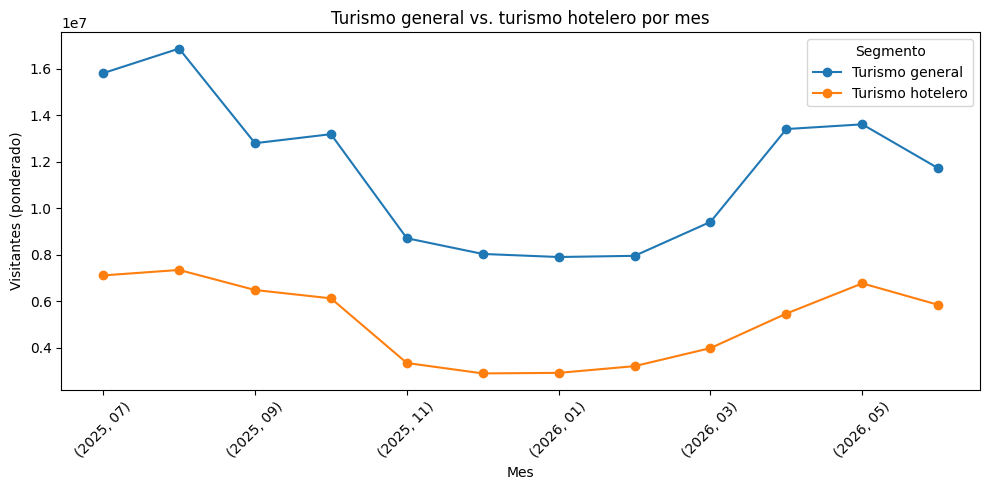

In [46]:
# Grafico 1 - Comparación de estacionalidad por turismo general vs. turismo hotelero por mes:

import pandas as pd

comparacion = pd.DataFrame({
    'Turismo general': visitantes_por_mes,
    'Turismo hotelero': visitantes_hotel_mes
})

comparacion.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Turismo general vs. turismo hotelero por mes')
plt.xlabel('Mes')
plt.ylabel('Visitantes (ponderado)')
plt.xticks(rotation=45)
plt.legend(title='Segmento')
plt.tight_layout()
plt.savefig('grafico1_general_vs_hotel.png', dpi=150, bbox_inches='tight')
plt.show()

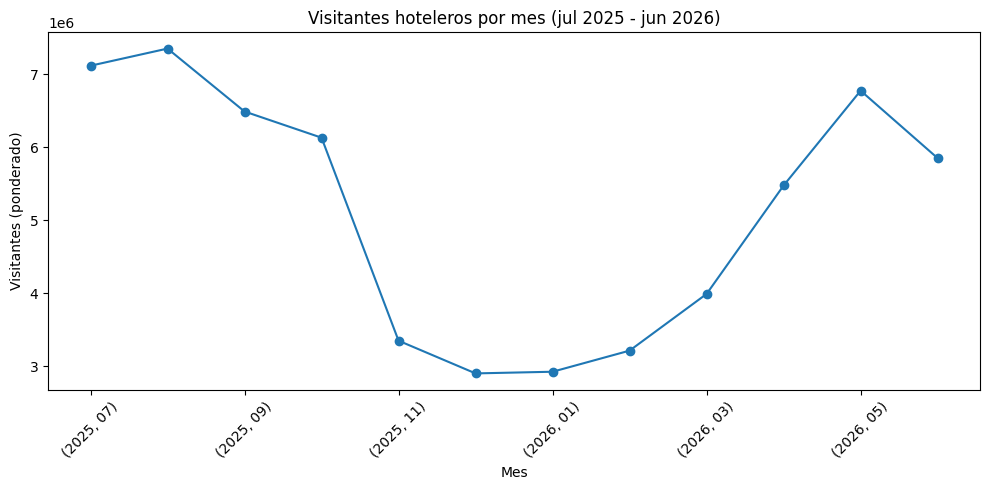

In [47]:
# Gráfico 2 — Evolución mensual de visitantes hoteleros (curva de estacionalidad general):

import matplotlib.pyplot as plt

visitantes_hotel_mes.plot(kind='line', marker='o', figsize=(10,5))
plt.title("Visitantes hoteleros por mes (jul 2025 - jun 2026)")
plt.xlabel("Mes")
plt.ylabel("Visitantes (ponderado)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafico2_visitantes_hoteleros_mes.png', dpi=150, bbox_inches='tight')
plt.show()

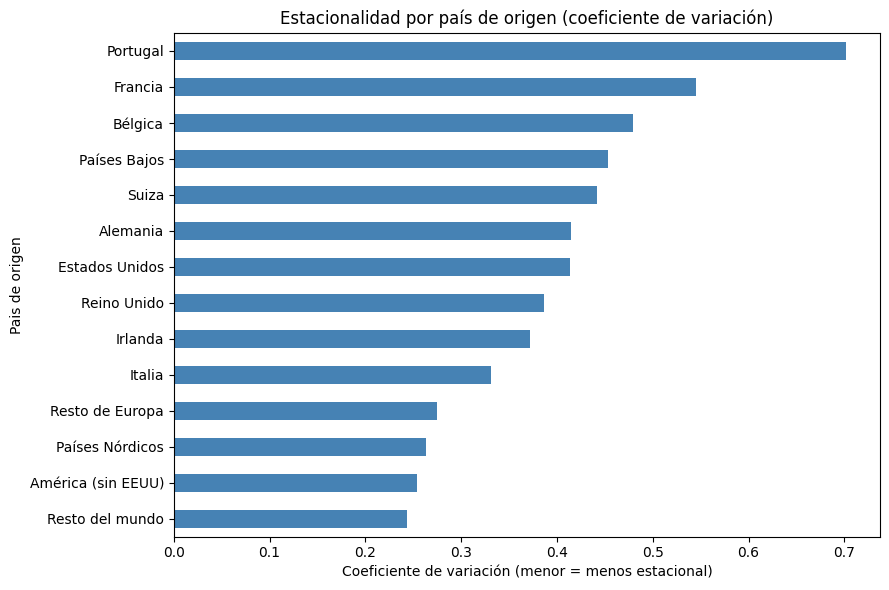

In [48]:
# Gráfico 3 — Comparación de estacionalidad por país (barras horizontales, del menos al más estacional):

estacionalidad.sort_values().plot(kind='barh', figsize=(9,6), color='steelblue')
plt.title("Estacionalidad por país de origen (coeficiente de variación)")
plt.xlabel("Coeficiente de variación (menor = menos estacional)")
plt.ylabel("Pais de origen")
plt.tight_layout()
plt.savefig('grafico3_estacionalidad_por_pais.png', dpi=150, bbox_inches='tight')
plt.show()

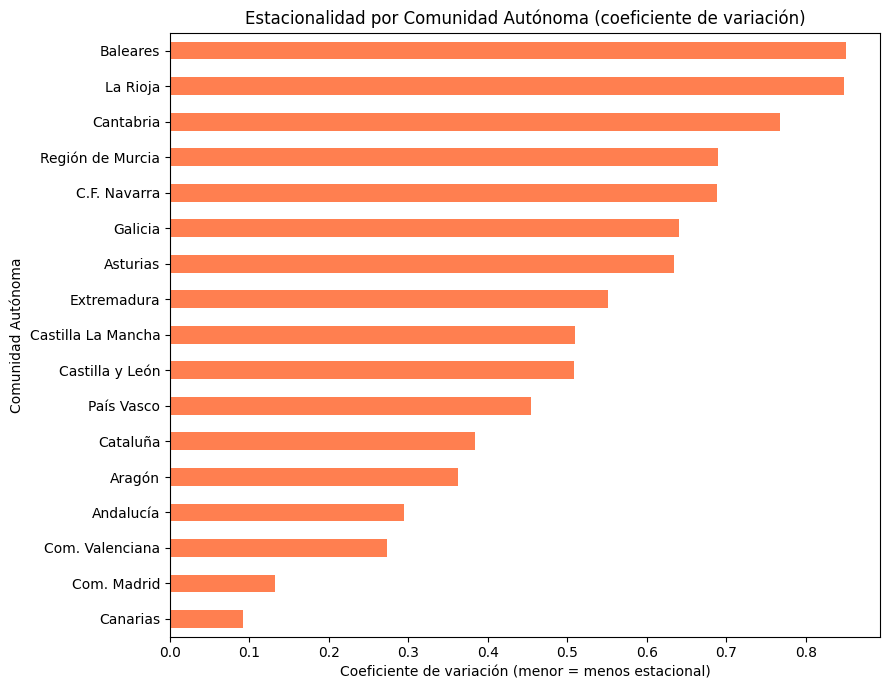

In [49]:
# Grafico 4 - Estacionalidad por Comunidad Autónoma:

estacionalidad_ccaa_filtrado = estacionalidad_ccaa.drop(['Ceuta', 'Melilla'])

estacionalidad_ccaa_filtrado.sort_values().plot(kind='barh', figsize=(9,7), color='coral')
plt.title('Estacionalidad por Comunidad Autónoma (coeficiente de variación)')
plt.xlabel('Coeficiente de variación (menor = menos estacional)')
plt.ylabel('Comunidad Autónoma')
plt.tight_layout()
plt.savefig('grafico4_estacionalidad_por_ccaa.png', dpi=150, bbox_inches='tight')
plt.show()

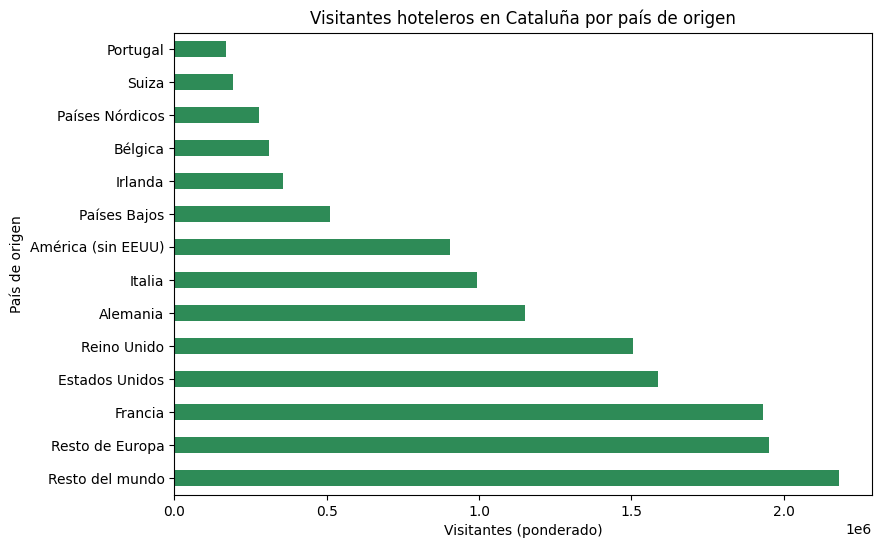

In [50]:
# Grafico 5 - Países que más visittan Cataluña:

cataluna_paises.plot(kind='barh', figsize=(9,6), color='seagreen')
plt.title("Visitantes hoteleros en Cataluña por país de origen")
plt.xlabel("Visitantes (ponderado)")
plt.ylabel("País de origen")
plt.tight_layout
plt.savefig('grafico5_visitantes_catalunya_.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
# Calculamos la estacionalidad de Italia específicamente en Cataluña, para comparar con su cifra a nivel España (0,33):

italia_cataluna = df_final[
    (df_final['comunidad_autonoma'] == 'Cataluña') &
    (df_final['pais_origen'] == 'Italia')
].groupby('anio_mes')['factor'].sum()

italia_cataluna


anio_mes
(2025, 07)    114144.653345
(2025, 08)    159012.524818
(2025, 09)     70824.773044
(2025, 10)     84624.224564
(2025, 11)     76836.366162
(2025, 12)     65577.705033
(2026, 01)     55717.605316
(2026, 02)     50852.089911
(2026, 03)     55223.391031
(2026, 04)    101570.011982
(2026, 05)     99284.322421
(2026, 06)     59331.700441
Name: factor, dtype: float64

In [43]:
italia_cataluna = df_final[
    (df_final['pais_origen'] == 'Italia') &
    (df_final['comunidad_autonoma'] == 'Cataluña')
]

italia_cataluna_mes = italia_cataluna.groupby('anio_mes')['factor'].sum()
italia_cataluna_mes

# También calculamos su coeficiente de variación específico
coef_italia_cataluna = italia_cataluna_mes.std() / italia_cataluna_mes.mean()
print(f'Coeficiente de variación Italia en Cataluña: {coef_italia_cataluna:.2f}')

Coeficiente de variación Italia en Cataluña: 0.38


In [ ]:
# Coeficiente de variación de pais dentro de Cataluña:

estacionalidad_pais_cataluna = df_final[df_final['comunidad_autonoma'] == 'Cataluña'].groupby(['pais_origen', 'anio_mes'])['factor'].sum().unstack()

media_pc = estacionalidad_pais_cataluna.mean(axis=1)
desviacion_pc = estacionalidad_pais_cataluna.std(axis=1)
estacionalidad_pc = (desviacion_pc / media_pc).sort_values()
estacionalidad_pc

pais_origen
Resto del mundo       0.223554
Resto de Europa       0.316985
Italia                0.381438
América (sin EEUU)    0.388963
Estados Unidos        0.499648
Suiza                 0.513667
Alemania              0.537535
Países Nórdicos       0.611751
Reino Unido           0.622640
Francia               0.625780
Irlanda               0.660806
Portugal              0.664525
Bélgica               0.672708
Países Bajos          0.745366
dtype: float64

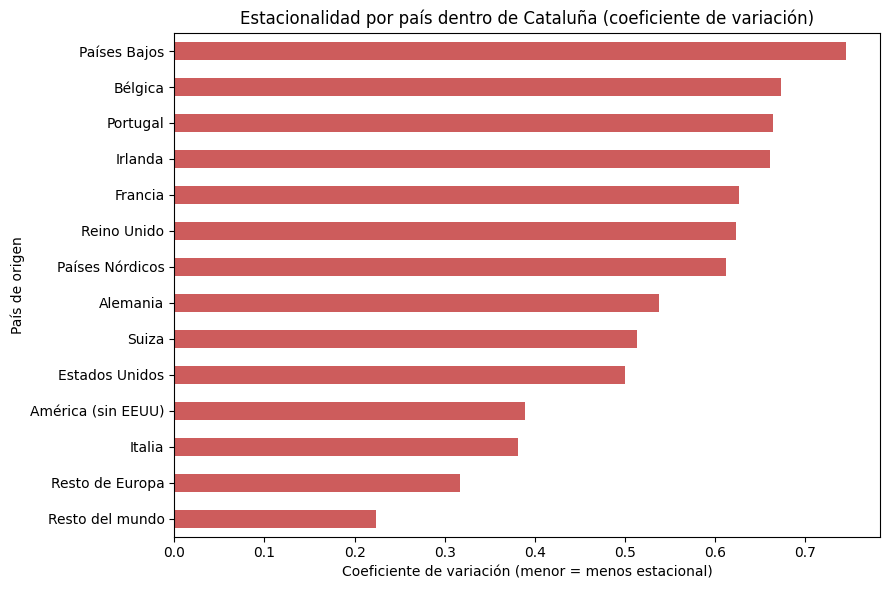

In [51]:
# Grafico 6 - Estacionalidad por país dentro de Cataluña:

estacionalidad_pc.sort_values().plot(kind='barh', figsize=(9,6), color='indianred')
plt.title('Estacionalidad por país dentro de Cataluña (coeficiente de variación)')
plt.xlabel('Coeficiente de variación (menor = menos estacional)')
plt.ylabel('País de origen')
plt.tight_layout()
plt.savefig('grafico6_estacionalidad_pais_cataluna.png', dpi=150, bbox_inches='tight')
plt.show()